# Regresión Logística Múltiple

**Universidad Nacional del Altiplano**

## Anemia infantil - ENDES 2024 (RECH6)

**Contexto:**
La anemia infantil es un problema de salud pública prioritario en el Perú. El Ministerio de Salud (MINSA) y el INEI monitorean su prevalencia a través de la Encuesta Demográfica y de Salud Familiar (ENDES), aplicando la Directriz OMS 2024 / RM 251-2024-MINSA para clasificar el nivel de hemoglobina ajustado por altitud en niños menores de 5 años.

**Contenido:** se utiliza el módulo individual de niños (RECH6) de la ENDES 2024 para identificar qué variables antropométricas (edad, peso, talla y los z-scores de crecimiento de la OMS) se asocian con la presencia de anemia infantil, mediante un modelo de regresión logística múltiple.

**Fuente de datos:** Instituto Nacional de Estadística e Informática (INEI) - Encuesta Demográfica y de Salud Familiar (ENDES) 2024, módulo RECH6 (Cuestionario Individual - Niños).

**Variable dependiente (Y):** `grupo_anemia`, con 2 categorías:
- `Sin_anemia`: niños clasificados sin anemia (Directriz OMS 2024 / RM 251-2024-MINSA, código HC57A = 4)
- `Con_anemia`: niños con anemia (Leve, Moderada o Grave agrupadas, código HC57A = 1, 2 ó 3)

**Variables independientes (X)** — todas cuantitativas, tal como exige el LDA/regresión logística:

| Variable | Descripción | Código ENDES |
|---|---|---|
| `edad_meses` | Edad del niño en meses | HC1 |
| `peso_kg` | Peso en kilogramos | HC2 |
| `talla_cm` | Talla en centímetros | HC3 |
| `talla_edad_z` | Z-score Talla/Edad (OMS) | HC70 |
| `peso_edad_z` | Z-score Peso/Edad (OMS) | HC71 |

> Se excluye la hemoglobina (HC53/HC56/HC56A) como predictor porque es la variable que define la anemia (evitar circularidad / fuga de información).

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, log_loss, precision_recall_curve,
                              average_precision_score, f1_score, precision_score, recall_score,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SequentialFeatureSelector
import itertools
from itertools import combinations

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración matplotlib
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad (misma semilla usada en el analisis LDA)
np.random.seed(123)

## Importing the dataset

In [2]:
from google.colab import files
uploaded = files.upload()
# selecciona RECH6_2024.csv (archivo original, sin modificar)

Saving RECH6_2024.csv to RECH6_2024.csv


## Paso 0.1: Preparación del dataset desde el archivo crudo

El archivo de ENDES usa códigos numéricos para "valor no medido" (documentados en el diccionario INEI). Se excluyen esos códigos (no se alteran datos reales) y se convierten las unidades a su valor real (peso y talla traían un decimal implícito; los z-scores traían 2 decimales implícitos).

In [3]:
# =====================================================================
# PASO 0.1: PREPARACION DEL DATASET (a partir del archivo crudo RECH6_2024.csv)
# =====================================================================

print("=" * 70)
print("PASO 0.1: PREPARACION DEL DATASET DESDE EL ARCHIVO CRUDO")
print("=" * 70)

df_crudo = pd.read_csv("RECH6_2024.csv", sep=";", low_memory=False)
print(f"\nDataset original (crudo): {df_crudo.shape}")

datos = df_crudo[['HC1', 'HC2', 'HC3', 'HC57A', 'HC70', 'HC71']].copy()
datos.columns = ['edad_meses', 'peso_kg_x10', 'talla_cm_x10', 'anemia_oms',
                  'talla_edad_z_x100', 'peso_edad_z_x100']

mask_validos = (
    (datos['peso_kg_x10'] < 999) &
    (datos['talla_cm_x10'] < 9999) &
    (datos['anemia_oms'].isin([1, 2, 3, 4])) &
    (datos['talla_edad_z_x100'].abs() < 9000) &
    (datos['peso_edad_z_x100'].abs() < 9000)
)
print(f"\nFilas excluidas por codigo de 'no medido': {(~mask_validos).sum()}")
print(f"Filas validas: {mask_validos.sum()} de {len(datos)}")

datos = datos[mask_validos].copy()
datos['peso_kg'] = datos['peso_kg_x10'] / 10
datos['talla_cm'] = datos['talla_cm_x10'] / 10
datos['talla_edad_z'] = datos['talla_edad_z_x100'] / 100
datos['peso_edad_z'] = datos['peso_edad_z_x100'] / 100
datos['grupo_anemia'] = np.where(datos['anemia_oms'] == 4, 'Sin_anemia', 'Con_anemia')

datos = datos[['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z',
               'anemia_oms', 'grupo_anemia']].copy()

X_cols = ['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z']
Y_col = 'grupo_anemia'

print(f"\nDataset final, listo para la regresion logistica:")
print(datos.shape)
print("\nDistribucion de la variable dependiente:")
print(datos[Y_col].value_counts())
print((datos[Y_col].value_counts(normalize=True).round(3) * 100), "%")

PASO 0.1: PREPARACION DEL DATASET DESDE EL ARCHIVO CRUDO

Dataset original (crudo): (20290, 43)

Filas excluidas por codigo de 'no medido': 1984
Filas validas: 18306 de 20290

Dataset final, listo para la regresion logistica:
(18306, 7)

Distribucion de la variable dependiente:
grupo_anemia
Sin_anemia    12552
Con_anemia     5754
Name: count, dtype: int64
grupo_anemia
Sin_anemia    68.6
Con_anemia    31.4
Name: proportion, dtype: float64 %


Cambiar formato de int a object, si se requiere: por ejemplo `datos['edad_meses'] = datos['edad_meses'].astype('object')`. En este caso no se requiere; las 5 variables independientes son cuantitativas continuas/discretas, tal como exige el modelo.

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18306 entries, 0 to 20289
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad_meses    18306 non-null  int64  
 1   peso_kg       18306 non-null  float64
 2   talla_cm      18306 non-null  float64
 3   talla_edad_z  18306 non-null  float64
 4   peso_edad_z   18306 non-null  float64
 5   anemia_oms    18306 non-null  int64  
 6   grupo_anemia  18306 non-null  object 
dtypes: float64(4), int64(2), object(1)
memory usage: 1.1+ MB


In [5]:
# Estadística descriptiva
datos[X_cols].describe().round(2)

,edad_meses,peso_kg,talla_cm,talla_edad_z,peso_edad_z
count,18306.00,18306.00,18306.00,18306.00,18306.00
mean,32.53,13.27,88.89,-0.88,-0.14
std,15.60,3.46,11.82,1.01,1.04
min,6.00,4.90,55.20,-5.51,-4.54
25%,19.00,10.60,79.60,-1.55,-0.83
50%,33.00,13.10,89.90,-0.88,-0.18
75%,46.00,15.60,98.30,-0.20,0.49
max,59.00,31.90,119.00,3.54,4.43


## Análisis exploratorio

Número de observaciones por clase
grupo_anemia
Sin_anemia    12552
Con_anemia     5754
Name: count, dtype: int64

Porcentaje de observaciones por clase
grupo_anemia
Sin_anemia    68.57
Con_anemia    31.43
Name: proportion, dtype: float64


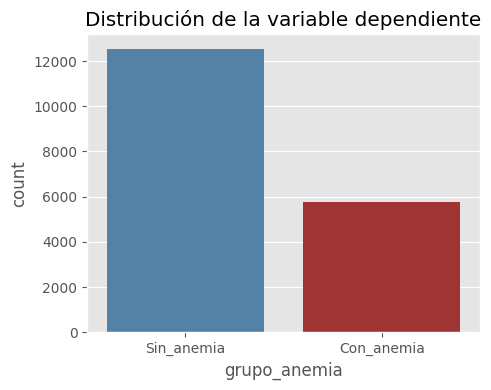

In [6]:
# Analisis exploratorio: distribucion de la variable dependiente
print("Número de observaciones por clase")
print(datos[Y_col].value_counts())
print("")
print("Porcentaje de observaciones por clase")
print((datos[Y_col].value_counts(normalize=True) * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=datos, x=Y_col, ax=ax, palette={'Sin_anemia': 'steelblue', 'Con_anemia': 'firebrick'})
ax.set_title('Distribución de la variable dependiente')
plt.tight_layout()
plt.show()

Observamos un desbalance moderado (~31% con anemia / ~69% sin anemia). Se mantiene el dataset completo; más adelante se evalúa el modelo con métricas que no dependen solo del accuracy (AUC-ROC, recall, F1).

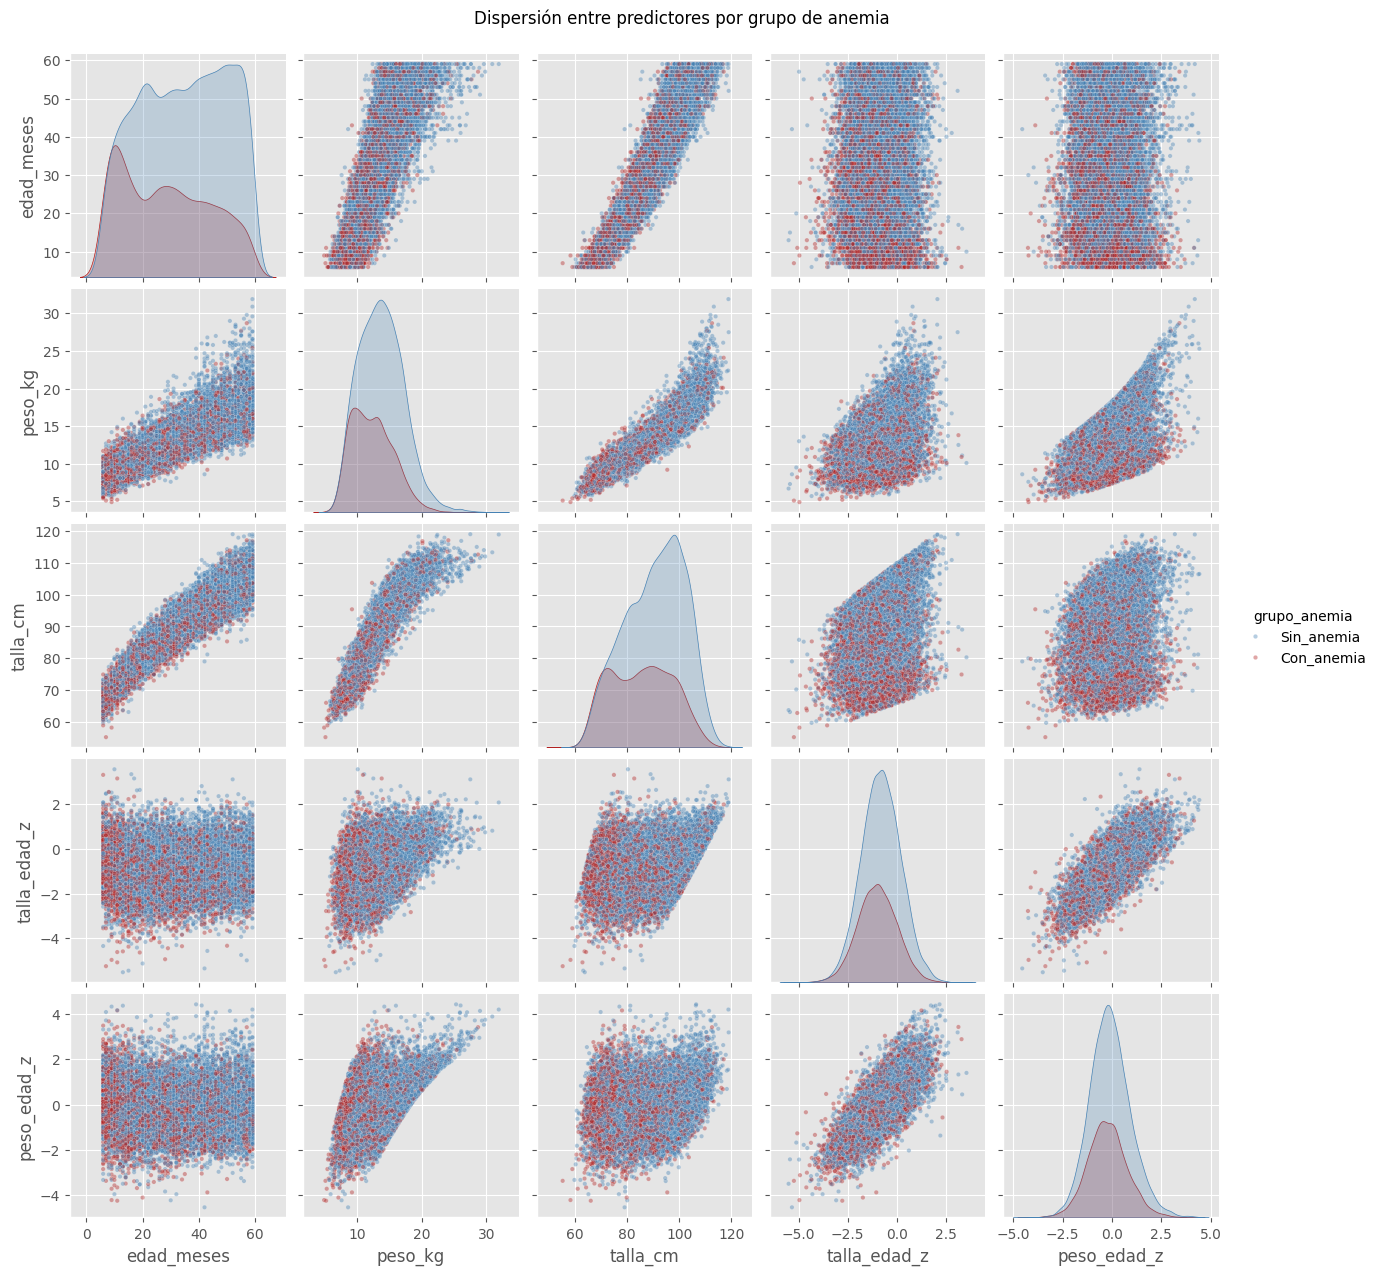

In [7]:
sns.pairplot(data=datos[X_cols + [Y_col]], hue=Y_col,
             palette={'Sin_anemia': 'steelblue', 'Con_anemia': 'firebrick'},
             diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle("Dispersión entre predictores por grupo de anemia", y=1.02)
plt.show()

Recodificando y convirtiendo a numérico la variable objetivo `grupo_anemia`

In [8]:
datos['grupo_anemia'] = datos['grupo_anemia'].map({'Con_anemia': 1, 'Sin_anemia': 0}).astype(int)

In [9]:
datos.dtypes

,0
edad_meses,int64
peso_kg,float64
talla_cm,float64
talla_edad_z,float64
peso_edad_z,float64
anemia_oms,int64
grupo_anemia,int64


**Codificación:** `Con_anemia = 1` (evento de interés) y `Sin_anemia = 0` (categoría de referencia). Esto significa que los Odds Ratios e interpretaciones del modelo se leen como "probabilidad de tener anemia".

## Variables ya cuantitativas (no se requiere One-Hot Encoding)

A diferencia del ejemplo de enfermedad cardíaca (que mezclaba variables categóricas y numéricas y requería `pd.get_dummies`), aquí **las 5 variables independientes ya son cuantitativas** (edad, peso, talla y dos z-scores), por lo cual no se aplica codificación dummy. Se trabaja directamente con `df_processing = datos.copy()`.

In [10]:
# creamos una nueva data (analoga a df_processing del ejemplo, sin necesidad de dummies)
df_processing = datos[X_cols + [Y_col]].copy()
df_processing.head(10)

,edad_meses,peso_kg,talla_cm,talla_edad_z,peso_edad_z,grupo_anemia
0,43,15.0,96.2,-0.88,-0.10,0
1,13,9.1,71.4,-1.67,-0.17,0
2,19,11.9,80.2,-0.78,0.91,0
3,13,10.0,74.7,-0.27,0.67,1
4,18,11.2,79.5,-1.19,0.13,0
5,54,16.7,101.2,-1.19,-0.25,0
6,21,9.6,77.7,-2.05,-1.07,0
7,42,14.3,96.7,-0.87,-0.62,0
8,53,14.6,103.0,-0.67,-1.14,1
10,14,9.9,76.7,-0.24,0.28,1


Correlaciones

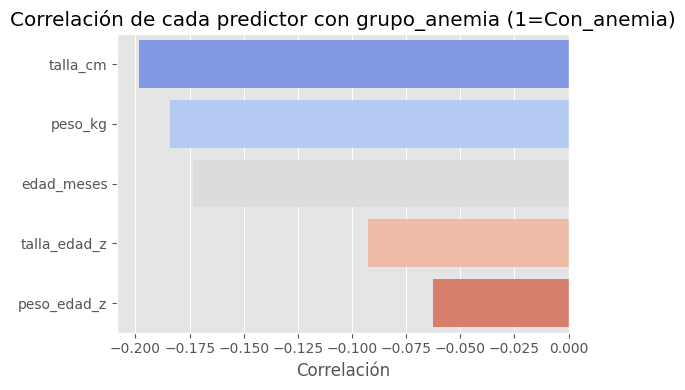

          index  grupo_anemia
0      talla_cm     -0.198512
1       peso_kg     -0.183895
2    edad_meses     -0.173468
3  talla_edad_z     -0.092452
4   peso_edad_z     -0.062687


In [11]:
plt.figure(figsize=(6, 4))
corr = df_processing.corr()[Y_col].drop(Y_col).sort_values(ascending=True).reset_index()
corr.columns = ['index', Y_col]
sns.barplot(data=corr, x=Y_col, y='index', palette='coolwarm')
plt.title('Correlación de cada predictor con grupo_anemia (1=Con_anemia)')
plt.xlabel('Correlación')
plt.ylabel('')
plt.tight_layout()
plt.show()
print(corr)

`grupo_anemia` está relacionado, sobre todo, con `talla_edad_z` y `peso_edad_z` (a menor z-score, mayor probabilidad de anemia), y en menor medida con `edad_meses`, `peso_kg` y `talla_cm`.


📊 Correlación con variable objetivo:
peso_edad_z    -0.062687
talla_edad_z   -0.092452
edad_meses     -0.173468
peso_kg        -0.183895
talla_cm       -0.198512
Name: grupo_anemia, dtype: float64


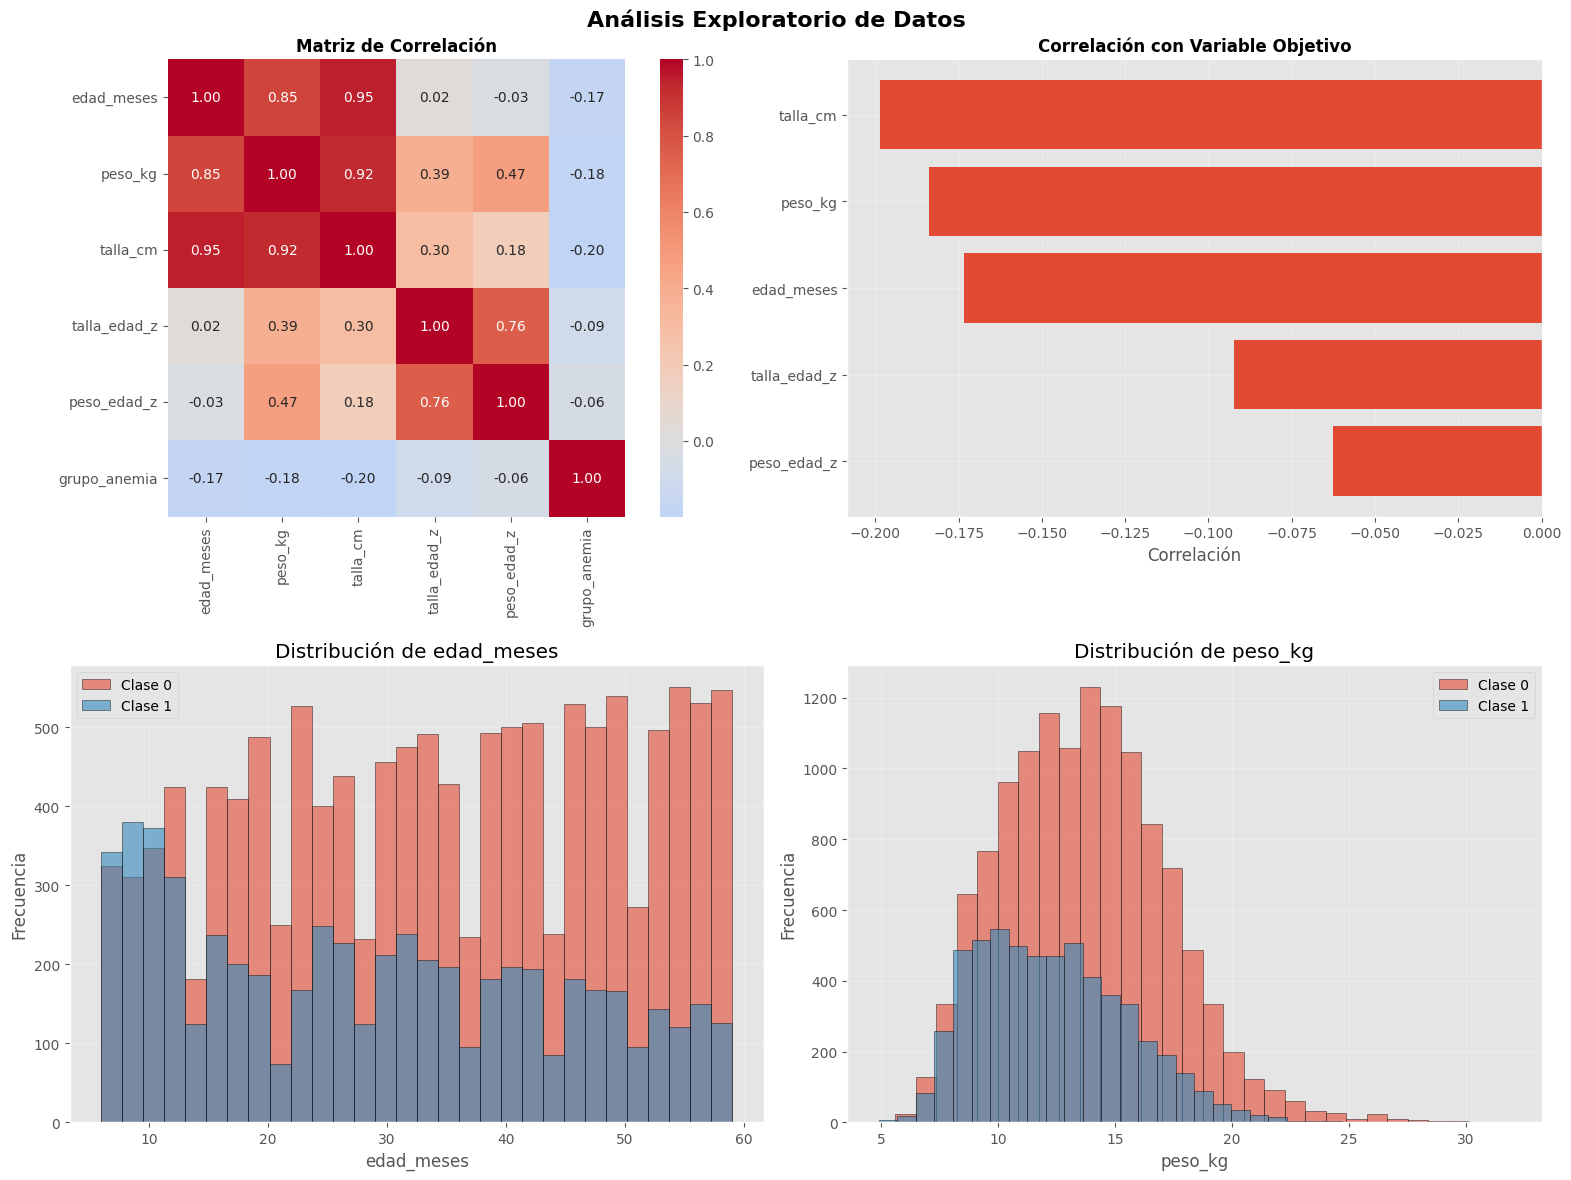

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Exploratorio de Datos', fontsize=16, fontweight='bold')

# Matriz de correlación
corr_matrix = df_processing.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0, 0], square=True)
axes[0, 0].set_title('Matriz de Correlación', fontsize=12, fontweight='bold')

# Correlación con variable objetivo
target_corr = corr_matrix[Y_col].drop(Y_col).sort_values(ascending=False)
axes[0, 1].barh(range(len(target_corr)), target_corr.values)
axes[0, 1].set_yticks(range(len(target_corr)))
axes[0, 1].set_yticklabels(target_corr.index)
axes[0, 1].set_xlabel('Correlación')
axes[0, 1].set_title('Correlación con Variable Objetivo', fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].grid(True, alpha=0.3)

print("\n📊 Correlación con variable objetivo:")
print(target_corr)

# Distribución de variables por clase
variables_continuas = X_cols
for i, var in enumerate(variables_continuas[:2]):
    ax = axes[1, i]
    for clase in [0, 1]:
        data = df_processing[df_processing[Y_col] == clase][var]
        ax.hist(data, bins=30, alpha=0.6, label=f'Clase {clase}', edgecolor='black')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {var}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

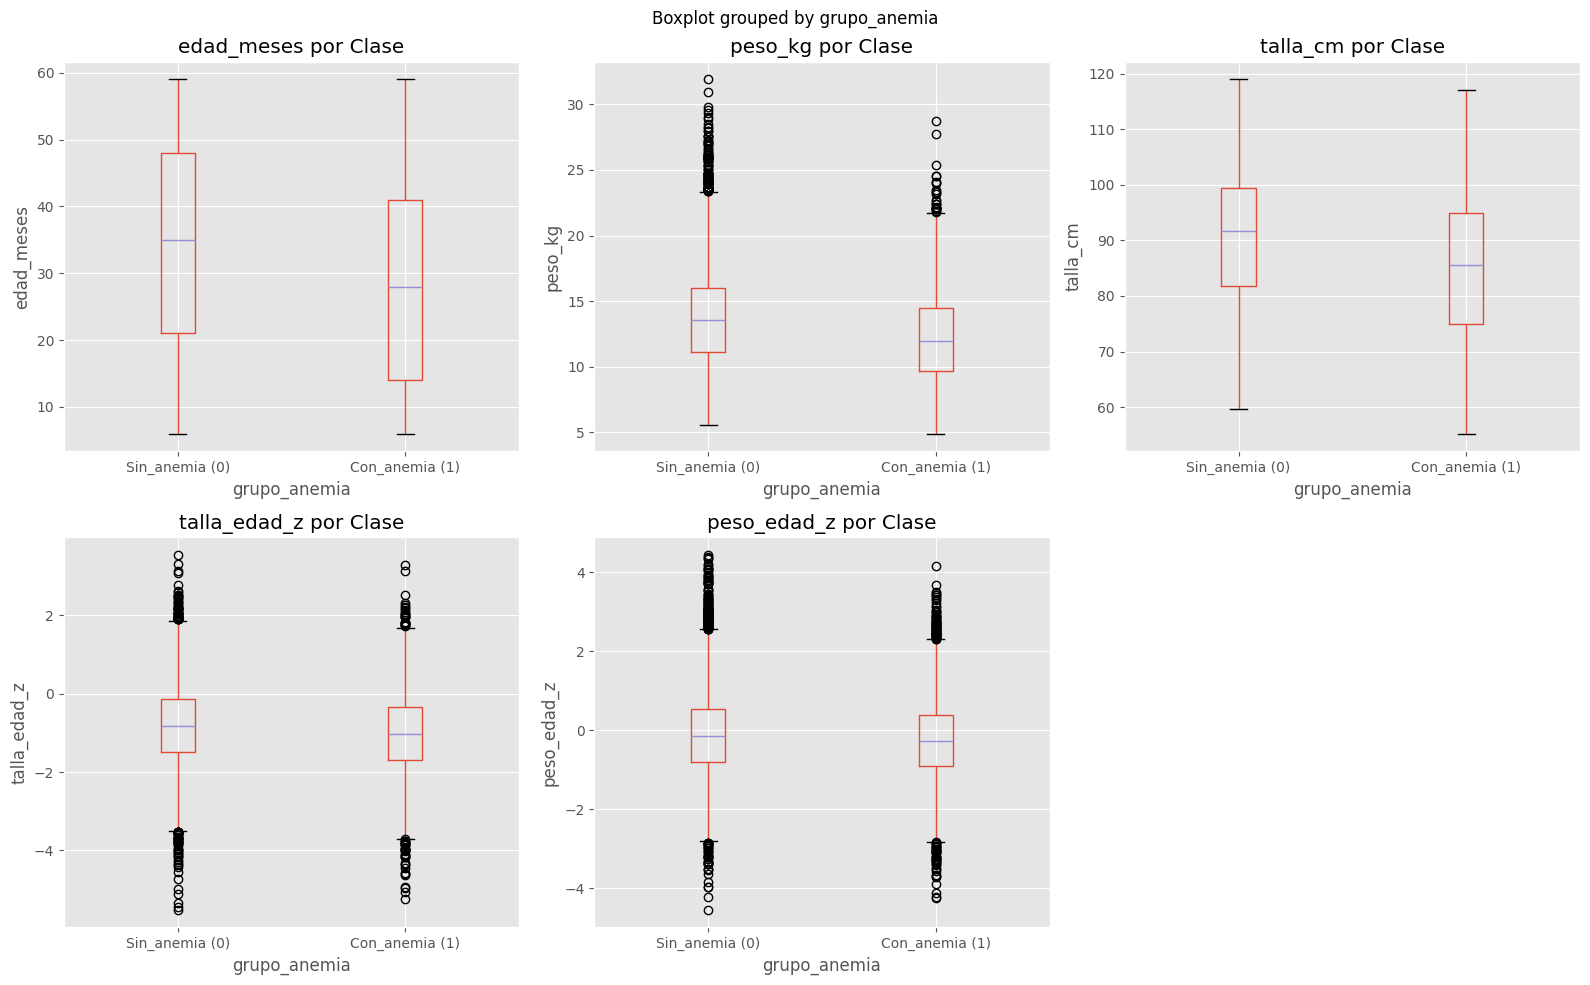


📊 Generando pairplot...


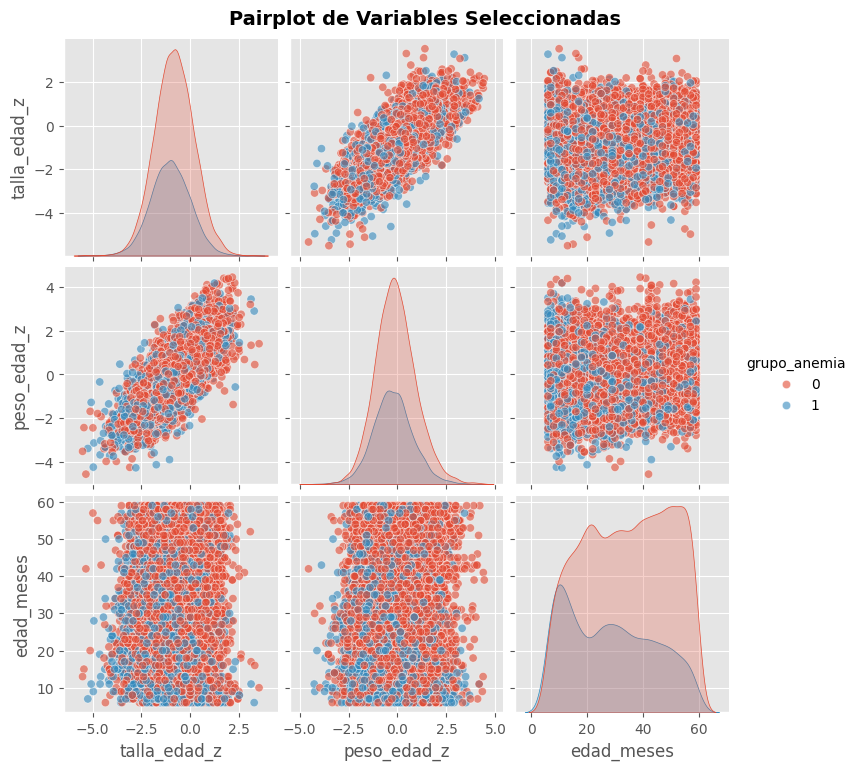

In [13]:
# 2.2 Boxplots comparativos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables por Clase (0=Sin_anemia, 1=Con_anemia)', fontsize=16, fontweight='bold')

axes = axes.flatten()
for i, var in enumerate(variables_continuas):
    df_processing.boxplot(column=var, by=Y_col, ax=axes[i])
    axes[i].set_xlabel('grupo_anemia')
    axes[i].set_ylabel(var)
    axes[i].set_title(f'{var} por Clase')
    plt.sca(axes[i])
    plt.xticks([1, 2], ['Sin_anemia (0)', 'Con_anemia (1)'])
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# 2.3 Pairplot (muestra de variables)
print("\n📊 Generando pairplot...")
vars_pairplot = ['talla_edad_z', 'peso_edad_z', 'edad_meses', Y_col]
sns.pairplot(df_processing[vars_pairplot], hue=Y_col, diag_kind='kde',
             plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Pairplot de Variables Seleccionadas', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Detección de multicolinealidad (VIF)


📊 Factor de Inflación de Varianza (VIF):
    Variable        VIF
     peso_kg 572.842828
    talla_cm 291.286835
  edad_meses  61.345556
 peso_edad_z  11.767867
talla_edad_z   4.578345

💡 Interpretación:
  VIF < 5: No hay multicolinealidad
  5 ≤ VIF < 10: Multicolinealidad moderada
  VIF ≥ 10: Multicolinealidad alta (considerar eliminar)


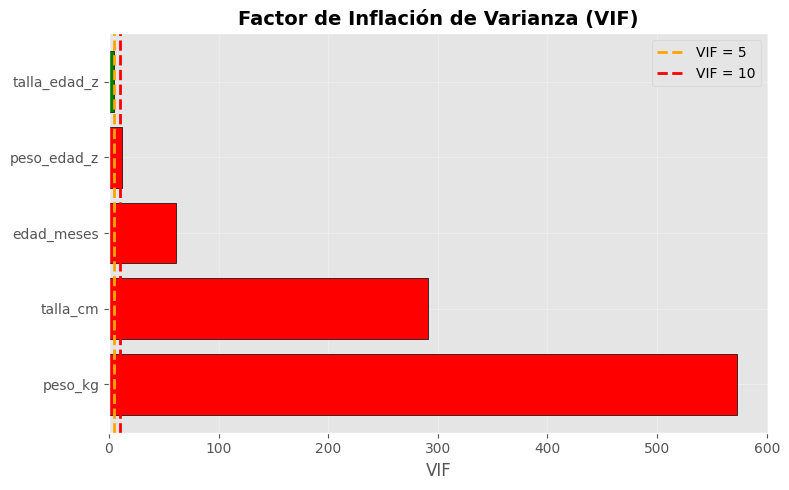

In [14]:
# 3. DETECCIÓN DE MULTICOLINEALIDAD (VIF)
X_features = df_processing[X_cols].astype(float)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_features.columns
vif_data["VIF"] = [variance_inflation_factor(X_features.values, i)
                    for i in range(X_features.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n📊 Factor de Inflación de Varianza (VIF):")
print(vif_data.to_string(index=False))
print("\n💡 Interpretación:")
print("  VIF < 5: No hay multicolinealidad")
print("  5 ≤ VIF < 10: Multicolinealidad moderada")
print("  VIF ≥ 10: Multicolinealidad alta (considerar eliminar)")

# Visualizar VIF
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if x < 5 else 'orange' if x < 10 else 'red' for x in vif_data['VIF']]
ax.barh(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='black')
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='VIF = 5')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10')
ax.set_xlabel('VIF')
ax.set_title('Factor de Inflación de Varianza (VIF)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nota esperada:** `peso_kg` y `talla_cm` suelen mostrar VIF alto entre sí (un niño más alto pesa más), y también con `edad_meses` (el cuerpo crece con la edad). Los z-scores (`talla_edad_z`, `peso_edad_z`) ya están estandarizados por edad y sexo según la OMS, por lo que típicamente presentan menor VIF. Si el VIF de `peso_kg`/`talla_cm`/`edad_meses` resulta muy alto (≥10), se puede optar por un modelo más parsimonioso usando solo los z-scores (ver sección de selección de variables).

## Entrenamiento con regresión logística múltiple

In [15]:
X = df_processing[X_cols]
y = df_processing[Y_col]

## Splitting the dataset into the Training set and Test set

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,
                                        random_state = 123,
                                        stratify     = y,
                                        shuffle      = True
                                    )

**Escalabilidad de datos.**

Escalaremos los datos debido a las diferencias de magnitud entre las variables, como la edad (0-59 meses), el peso (5-32 kg), la talla (55-119 cm) y los z-scores (aprox. -5 a +5). Esto evita que variables con escalas mayores (como `talla_cm`) dominen artificialmente el ajuste del modelo frente a las demás.

In [17]:
#####Escalando datos
# Apply scaling after the split
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [18]:
print(f"X_train:{X_train.shape}")
print(f"X_test:{X_test.shape}")
print()
print(f"y_train:{y_train.shape}")
print(f"y_test:{y_test.shape}")

X_train:(14644, 5)
X_test:(3662, 5)

y_train:(14644,)
y_test:(3662,)


## Training the Logistic Regression model on the Training set

In [19]:
from sklearn.linear_model import LogisticRegression
# Usamos el solver 'lbfgs', que es eficiente para datasets pequeños/medianos
modelo = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000, random_state=123)
# Fit the model with scaled data
result = modelo.fit(X_train_scaled_df, y_train)

In [20]:
# Obtener los coeficientes del modelo entrenado para cada variable
coefficients = modelo.coef_[0]
features = X.columns

# Crear un DataFrame para mostrar las variables con su coeficiente
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
})

# Ordenar las variables por el valor absoluto del coeficiente (importancia)
importance_df = importance_df.sort_values(by='Absolute Coefficient', ascending=False)
importance_df

,Feature,Coefficient,Absolute Coefficient
2,talla_cm,-2.737782,2.737782
1,peso_kg,-0.744361,0.744361
0,edad_meses,0.613016,0.613016
3,talla_edad_z,-0.485034,0.485034
4,peso_edad_z,0.327102,0.327102


In [21]:
# accuracy con datos test
from sklearn import metrics
pred_test = modelo.predict(X_test_scaled_df)
print(metrics.accuracy_score(y_test, pred_test))

0.6856908793009284


In [22]:
# accuracy con datos de entrenamiento
print("Intercepto del modelo:", modelo.intercept_)
print("Accuracy de entrenamiento:", modelo.score(X_train_scaled_df, y_train))

Intercepto del modelo: [0.6387819]
Accuracy de entrenamiento: 0.6846490030046435


In [23]:
y_pred = modelo.predict(X_test_scaled_df)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [24]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[2466,   45],
       [1106,   45]])

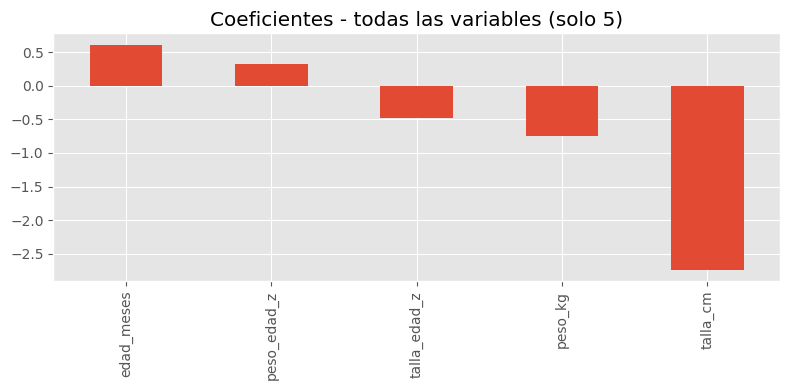

In [25]:
# evaluando el modelo
weights = pd.Series(modelo.coef_[0], index=X.columns.values)
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
weights.sort_values(ascending=False).plot(kind='bar', ax=axs, title='Coeficientes - todas las variables (solo 5)')
plt.tight_layout()
plt.show()

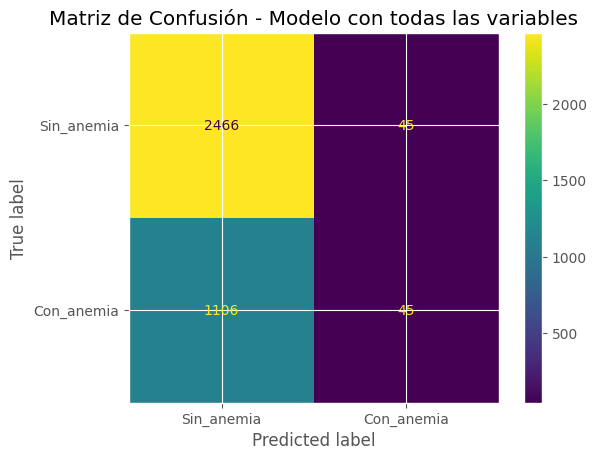

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin_anemia', 'Con_anemia'])
disp.plot()
plt.title('Matriz de Confusión - Modelo con todas las variables')
plt.show()

In [27]:
from sklearn.metrics import classification_report
target_names = ['Sin_anemia', 'Con_anemia']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

  Sin_anemia       0.69      0.98      0.81      2511
  Con_anemia       0.50      0.04      0.07      1151

    accuracy                           0.69      3662
   macro avg       0.60      0.51      0.44      3662
weighted avg       0.63      0.69      0.58      3662



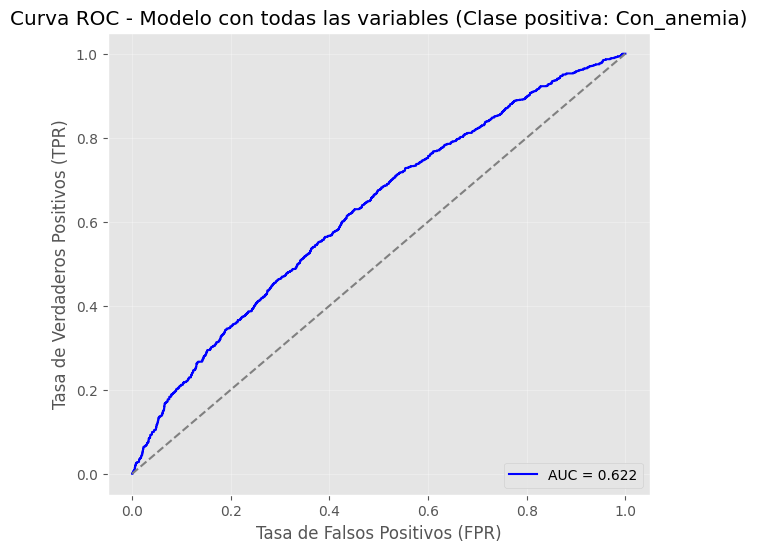

In [28]:
# Calcular las probabilidades de la clase positiva (Con_anemia = 1)
y_prob = modelo.predict_proba(X_test_scaled_df)[:, 1]

# Calcular la curva ROC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='b', label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo con todas las variables (Clase positiva: Con_anemia)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Predicting a new result

In [29]:
# nuevo caso hipotetico: nino de 24 meses, 11.5 kg, 84 cm, z-scores moderadamente bajos
X_new = pd.DataFrame({
    'edad_meses': [24],
    'peso_kg': [11.5],
    'talla_cm': [84.0],
    'talla_edad_z': [-1.2],
    'peso_edad_z': [-0.8]
})
# Reordenar columnas para que coincidan con X_train
X_new = X_new[X_train.columns]

# Escalar el nuevo caso con el mismo scaler ajustado en train
X_new_scaled = scaler.transform(X_new)

# Prediccion
prediction = modelo.predict(X_new_scaled)
prediction_proba = modelo.predict_proba(X_new_scaled)

clase_predicha = 'Con_anemia' if prediction[0] == 1 else 'Sin_anemia'
print("Prediction (0=Sin_anemia, 1=Con_anemia):", prediction)
print("Clase predicha:", clase_predicha)
print("Prediction Probability [P(Sin_anemia), P(Con_anemia)]:", prediction_proba)

Prediction (0=Sin_anemia, 1=Con_anemia): [0]
Clase predicha: Sin_anemia
Prediction Probability [P(Sin_anemia), P(Con_anemia)]: [[0.66048431 0.33951569]]


## Modelo con statsmodels (matrices, igual procedimiento que en scikit-learn)

In [30]:
# Creación del modelo utilizando matrices como en scikit-learn
# Variables cuantitativas: no requieren codificacion adicional
X_train_sm = sm.add_constant(X_train_scaled_df, prepend=True)
modelo1 = sm.Logit(endog=y_train.values, exog=X_train_sm)
modelo1 = modelo1.fit()
print(modelo1.summary())

Optimization terminated successfully.
         Current function value: 0.601484
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                14644
Model:                          Logit   Df Residuals:                    14638
Method:                           MLE   Df Model:                            5
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                 0.03379
Time:                        23:03:44   Log-Likelihood:                -8808.1
converged:                       True   LL-Null:                       -9116.2
Covariance Type:            nonrobust   LLR p-value:                6.776e-131
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7945      0.158      5.017      0.000       0.484       1.105
edad_meses       1.1890

## Selección de variables - múltiples métodos


SELECCIÓN DE VARIABLES

1️⃣ Método SelectKBest (ANOVA F-test):
------------------------------------------------------------
    Variable      Score       p-value
    talla_cm 603.280012 1.399481e-130
     peso_kg 520.817841 2.637059e-113
  edad_meses 454.844714  2.058067e-99
talla_edad_z 120.924327  5.109700e-28
 peso_edad_z  55.472485  1.000634e-13

✅ Top 3 variables: ['talla_cm', 'peso_kg', 'edad_meses']

2️⃣ Método RFE (Recursive Feature Elimination):
------------------------------------------------------------
    Variable  Ranking  Seleccionada
  edad_meses        1          True
    talla_cm        1          True
talla_edad_z        1          True
     peso_kg        2         False
 peso_edad_z        3         False

✅ Variables seleccionadas por RFE: ['edad_meses', 'talla_cm', 'talla_edad_z']

3️⃣ Método Forward Selection:
------------------------------------------------------------
✅ Variables seleccionadas: ['edad_meses', 'peso_kg', 'peso_edad_z']

4️⃣ Método Backward Eli

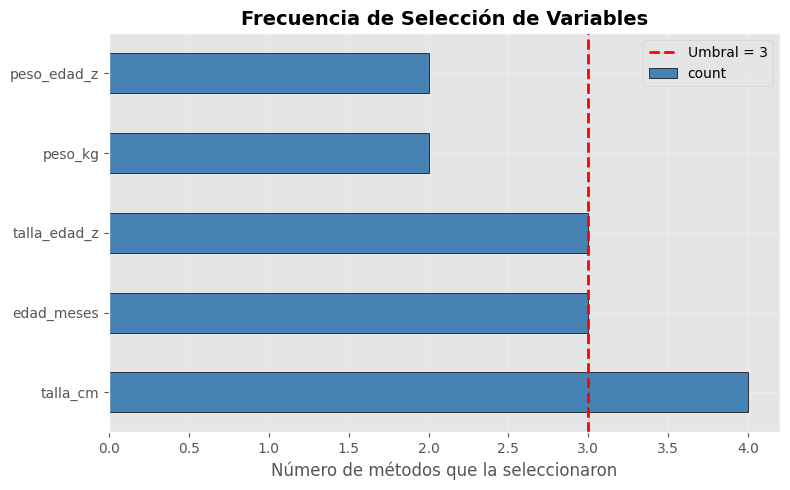

In [31]:
#==============================================
# 5. SELECCIÓN DE VARIABLES - MÚLTIPLES MÉTODOS
# =============================================

print("\n" + "=" * 80)
print("SELECCIÓN DE VARIABLES")
print("=" * 80)

resultados_seleccion = {}
k_best = 3  # con solo 5 predictores, pedimos un subconjunto razonable

# 5.1 Método 1: SelectKBest (ANOVA F-test)
print("\n1️⃣ Método SelectKBest (ANOVA F-test):")
print("-" * 60)

selector_kbest = SelectKBest(score_func=f_classif, k='all')
selector_kbest.fit(X_train_scaled, y_train)

scores_kbest = pd.DataFrame({
    'Variable': X.columns,
    'Score': selector_kbest.scores_,
    'p-value': selector_kbest.pvalues_
}).sort_values('Score', ascending=False)

print(scores_kbest.to_string(index=False))

top_k_vars = scores_kbest.head(k_best)['Variable'].tolist()
print(f"\n✅ Top {k_best} variables: {top_k_vars}")
resultados_seleccion['SelectKBest'] = top_k_vars

# 5.2 Método 2: RFE (Recursive Feature Elimination)
print("\n2️⃣ Método RFE (Recursive Feature Elimination):")
print("-" * 60)

modelo_base = LogisticRegression(random_state=123, max_iter=1000)
selector_rfe = RFE(estimator=modelo_base, n_features_to_select=k_best)
selector_rfe.fit(X_train_scaled, y_train)

rfe_results = pd.DataFrame({
    'Variable': X.columns,
    'Ranking': selector_rfe.ranking_,
    'Seleccionada': selector_rfe.support_
}).sort_values('Ranking')

print(rfe_results.to_string(index=False))

rfe_vars = rfe_results[rfe_results['Seleccionada']]['Variable'].tolist()
print(f"\n✅ Variables seleccionadas por RFE: {rfe_vars}")
resultados_seleccion['RFE'] = rfe_vars

# 5.3 Método 3: Forward Selection
print("\n3️⃣ Método Forward Selection:")
print("-" * 60)

selector_forward = SequentialFeatureSelector(
    modelo_base, n_features_to_select=k_best,
    direction='forward', cv=5
)
selector_forward.fit(X_train_scaled, y_train)

forward_vars = X.columns[selector_forward.get_support()].tolist()
print(f"✅ Variables seleccionadas: {forward_vars}")
resultados_seleccion['Forward'] = forward_vars

# 5.4 Método 4: Backward Elimination
print("\n4️⃣ Método Backward Elimination:")
print("-" * 60)

selector_backward = SequentialFeatureSelector(
    modelo_base, n_features_to_select=k_best,
    direction='backward', cv=5
)
selector_backward.fit(X_train_scaled, y_train)

backward_vars = X.columns[selector_backward.get_support()].tolist()
print(f"✅ Variables seleccionadas: {backward_vars}")
resultados_seleccion['Backward'] = backward_vars

# 5.5 Método 5: Regularización L1 (Lasso)
print("\n5️⃣ Método Regularización L1 (Lasso):")
print("-" * 60)

modelo_l1 = LogisticRegression(penalty='l1', solver='liblinear',
                                C=0.1, random_state=123)
modelo_l1.fit(X_train_scaled, y_train)

coef_l1 = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_l1.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coef_l1.to_string(index=False))

l1_vars = coef_l1[coef_l1['Coeficiente'] != 0]['Variable'].tolist()
print(f"\n✅ Variables con coeficiente no nulo: {l1_vars}")
resultados_seleccion['Lasso_L1'] = l1_vars

# 5.6 Resumen de selección de variables
print("\n" + "=" * 80)
print("RESUMEN DE SELECCIÓN DE VARIABLES")
print("=" * 80)

todas_vars = [var for vars_list in resultados_seleccion.values() for var in vars_list]
frecuencia = pd.Series(todas_vars).value_counts()

print("\n📊 Frecuencia de selección por variable:")
print(frecuencia.to_string())

umbral_seleccion = 3  # Seleccionadas en al menos 3 métodos
vars_finales = frecuencia[frecuencia >= umbral_seleccion].index.tolist()
if len(vars_finales) == 0:
    vars_finales = frecuencia.head(3).index.tolist()
print(f"\n✅ Variables seleccionadas en ≥{umbral_seleccion} métodos:")
print(f"   {vars_finales}")

fig, ax = plt.subplots(figsize=(8, 5))
frecuencia.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(x=umbral_seleccion, color='red', linestyle='--',
           linewidth=2, label=f'Umbral = {umbral_seleccion}')
ax.set_xlabel('Número de métodos que la seleccionaron')
ax.set_title('Frecuencia de Selección de Variables', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Entrenamiento de modelos candidatos

In [32]:
# =======================================
# 6. ENTRENAMIENTO DE MODELOS CANDIDATOS
# =======================================

print("\n" + "=" * 80)
print("ENTRENAMIENTO DE MODELOS CANDIDATOS")
print("=" * 80)

modelos_candidatos = {}

# 6.1 Modelo con todas las variables
print("\n1️⃣ Modelo COMPLETO (todas las variables):")
print("-" * 60)

modelo_completo = LogisticRegression(random_state=123, max_iter=1000)
modelo_completo.fit(X_train_scaled_df, y_train)

train_score_completo = modelo_completo.score(X_train_scaled_df, y_train)
test_score_completo = modelo_completo.score(X_test_scaled_df, y_test)
y_pred_proba_completo = modelo_completo.predict_proba(X_test_scaled_df)[:, 1]
auc_completo = roc_auc_score(y_test, y_pred_proba_completo)
logloss_completo = log_loss(y_test, y_pred_proba_completo)

modelos_candidatos['Completo'] = {
    'modelo': modelo_completo,
    'variables': X.columns.tolist(),
    'n_vars': len(X.columns),
    'train_score': train_score_completo,
    'test_score': test_score_completo,
    'auc': auc_completo,
    'log_loss': logloss_completo
}

print(f"Variables: {X.columns.tolist()}")
print(f"Accuracy Train: {train_score_completo:.4f}")
print(f"Accuracy Test: {test_score_completo:.4f}")
print(f"AUC-ROC: {auc_completo:.4f}")
print(f"Log Loss: {logloss_completo:.4f}")

# 6.2 Modelo con variables más frecuentes
print("\n2️⃣ Modelo con VARIABLES MÁS FRECUENTES:")
print("-" * 60)

X_train_freq = X_train_scaled_df[vars_finales]
X_test_freq = X_test_scaled_df[vars_finales]

modelo_frecuentes = LogisticRegression(random_state=123, max_iter=1000)
modelo_frecuentes.fit(X_train_freq, y_train)

train_score_freq = modelo_frecuentes.score(X_train_freq, y_train)
test_score_freq = modelo_frecuentes.score(X_test_freq, y_test)
y_pred_proba_freq = modelo_frecuentes.predict_proba(X_test_freq)[:, 1]
auc_freq = roc_auc_score(y_test, y_pred_proba_freq)
logloss_freq = log_loss(y_test, y_pred_proba_freq)

modelos_candidatos['Frecuentes'] = {
    'modelo': modelo_frecuentes,
    'variables': vars_finales,
    'n_vars': len(vars_finales),
    'train_score': train_score_freq,
    'test_score': test_score_freq,
    'auc': auc_freq,
    'log_loss': logloss_freq
}

print(f"Variables: {vars_finales}")
print(f"Accuracy Train: {train_score_freq:.4f}")
print(f"Accuracy Test: {test_score_freq:.4f}")
print(f"AUC-ROC: {auc_freq:.4f}")
print(f"Log Loss: {logloss_freq:.4f}")

# 6.3 Modelos con cada método de selección
for nombre_metodo, variables in resultados_seleccion.items():
    print(f"\n3️⃣ Modelo con {nombre_metodo}:")
    print("-" * 60)

    X_train_metodo = X_train_scaled_df[variables]
    X_test_metodo = X_test_scaled_df[variables]

    modelo_tmp = LogisticRegression(random_state=123, max_iter=1000)
    modelo_tmp.fit(X_train_metodo, y_train)

    train_score = modelo_tmp.score(X_train_metodo, y_train)
    test_score = modelo_tmp.score(X_test_metodo, y_test)
    y_pred_proba = modelo_tmp.predict_proba(X_test_metodo)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)

    modelos_candidatos[nombre_metodo] = {
        'modelo': modelo_tmp,
        'variables': variables,
        'n_vars': len(variables),
        'train_score': train_score,
        'test_score': test_score,
        'auc': auc_score,
        'log_loss': logloss
    }

    print(f"Variables: {variables}")
    print(f"Accuracy Train: {train_score:.4f}")
    print(f"Accuracy Test: {test_score:.4f}")
    print(f"AUC-ROC: {auc_score:.4f}")
    print(f"Log Loss: {logloss:.4f}")

# 6.4 Búsqueda exhaustiva (todas las combinaciones posibles)
# Con solo 5 variables, 2^5 - 1 = 31 combinaciones: computacionalmente viable
print("\n4️⃣ Búsqueda EXHAUSTIVA (todas las combinaciones):")
print("-" * 60)
print("⏳ Evaluando todas las combinaciones posibles...")

mejores_combinaciones = []

for r in range(1, len(X.columns) + 1):
    for combo in combinations(X.columns, r):
        combo_list = list(combo)

        X_train_combo = X_train_scaled_df[combo_list]
        X_test_combo = X_test_scaled_df[combo_list]

        modelo_tmp = LogisticRegression(random_state=123, max_iter=1000)
        modelo_tmp.fit(X_train_combo, y_train)

        test_score = modelo_tmp.score(X_test_combo, y_test)
        y_pred_proba = modelo_tmp.predict_proba(X_test_combo)[:, 1]
        auc_score = roc_auc_score(y_test, y_pred_proba)

        mejores_combinaciones.append({
            'variables': combo_list,
            'n_vars': len(combo_list),
            'test_score': test_score,
            'auc': auc_score
        })


ENTRENAMIENTO DE MODELOS CANDIDATOS

1️⃣ Modelo COMPLETO (todas las variables):
------------------------------------------------------------
Variables: ['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z']
Accuracy Train: 0.6846
Accuracy Test: 0.6857
AUC-ROC: 0.6220
Log Loss: 0.6024

2️⃣ Modelo con VARIABLES MÁS FRECUENTES:
------------------------------------------------------------
Variables: ['talla_cm', 'edad_meses', 'talla_edad_z']
Accuracy Train: 0.6850
Accuracy Test: 0.6868
AUC-ROC: 0.6228
Log Loss: 0.6021

3️⃣ Modelo con SelectKBest:
------------------------------------------------------------
Variables: ['talla_cm', 'peso_kg', 'edad_meses']
Accuracy Train: 0.6842
Accuracy Test: 0.6860
AUC-ROC: 0.6220
Log Loss: 0.6023

3️⃣ Modelo con RFE:
------------------------------------------------------------
Variables: ['edad_meses', 'talla_cm', 'talla_edad_z']
Accuracy Train: 0.6850
Accuracy Test: 0.6868
AUC-ROC: 0.6228
Log Loss: 0.6021

3️⃣ Modelo con Forward:
---------

In [33]:
# Ordenar por AUC
mejores_combinaciones = sorted(mejores_combinaciones,
                               key=lambda x: x['auc'], reverse=True)

print(f"\n✅ Se evaluaron {len(mejores_combinaciones)} combinaciones")
print("\n🏆 Top 5 mejores combinaciones:")
for i, combo in enumerate(mejores_combinaciones[:5], 1):
    print(f"\n  {i}. Variables: {combo['variables']}")
    print(f"     N° vars: {combo['n_vars']}")
    print(f"     Accuracy: {combo['test_score']:.4f}")
    print(f"     AUC: {combo['auc']:.4f}")

# Agregar mejor combinación a modelos candidatos
mejor_combo = mejores_combinaciones[0]
X_train_mejor = X_train_scaled_df[mejor_combo['variables']]
X_test_mejor = X_test_scaled_df[mejor_combo['variables']]

modelo_mejor = LogisticRegression(random_state=123, max_iter=1000)
modelo_mejor.fit(X_train_mejor, y_train)

train_score_mejor = modelo_mejor.score(X_train_mejor, y_train)
y_pred_proba_mejor = modelo_mejor.predict_proba(X_test_mejor)[:, 1]
logloss_mejor = log_loss(y_test, y_pred_proba_mejor)

modelos_candidatos['Mejor_Exhaustiva'] = {
    'modelo': modelo_mejor,
    'variables': mejor_combo['variables'],
    'n_vars': mejor_combo['n_vars'],
    'train_score': train_score_mejor,
    'test_score': mejor_combo['test_score'],
    'auc': mejor_combo['auc'],
    'log_loss': logloss_mejor
}


✅ Se evaluaron 31 combinaciones

🏆 Top 5 mejores combinaciones:

  1. Variables: ['edad_meses', 'talla_cm', 'talla_edad_z']
     N° vars: 3
     Accuracy: 0.6868
     AUC: 0.6228

  2. Variables: ['edad_meses', 'talla_cm', 'talla_edad_z', 'peso_edad_z']
     N° vars: 4
     Accuracy: 0.6871
     AUC: 0.6227

  3. Variables: ['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z']
     N° vars: 4
     Accuracy: 0.6871
     AUC: 0.6227

  4. Variables: ['edad_meses', 'talla_cm']
     N° vars: 2
     Accuracy: 0.6873
     AUC: 0.6225

  5. Variables: ['edad_meses', 'talla_cm', 'peso_edad_z']
     N° vars: 3
     Accuracy: 0.6857
     AUC: 0.6225


## Comparación de modelos y selección del mejor


COMPARACIÓN DE MODELOS

📊 Tabla Comparativa de Modelos:
          Modelo  N° Variables  Accuracy Train  Accuracy Test  AUC-ROC  Log Loss  Diff_Train_Test
      Frecuentes             3        0.684990       0.686783 0.622779  0.602082        -0.001793
             RFE             3        0.684990       0.686783 0.622779  0.602082        -0.001793
Mejor_Exhaustiva             3        0.684990       0.686783 0.622779  0.602082        -0.001793
        Lasso_L1             2        0.685946       0.686783 0.622462  0.602175        -0.000837
        Backward             3        0.685810       0.687602 0.622405  0.602173        -0.001793
        Completo             5        0.684649       0.685691 0.622029  0.602374        -0.001042
     SelectKBest             3        0.684171       0.685964 0.622011  0.602279        -0.001793
         Forward             3        0.685878       0.685964 0.613286  0.605299        -0.000086

CRITERIOS DE SELECCIÓN DEL MEJOR MODELO

1️⃣ Mejor AUC-ROC: 

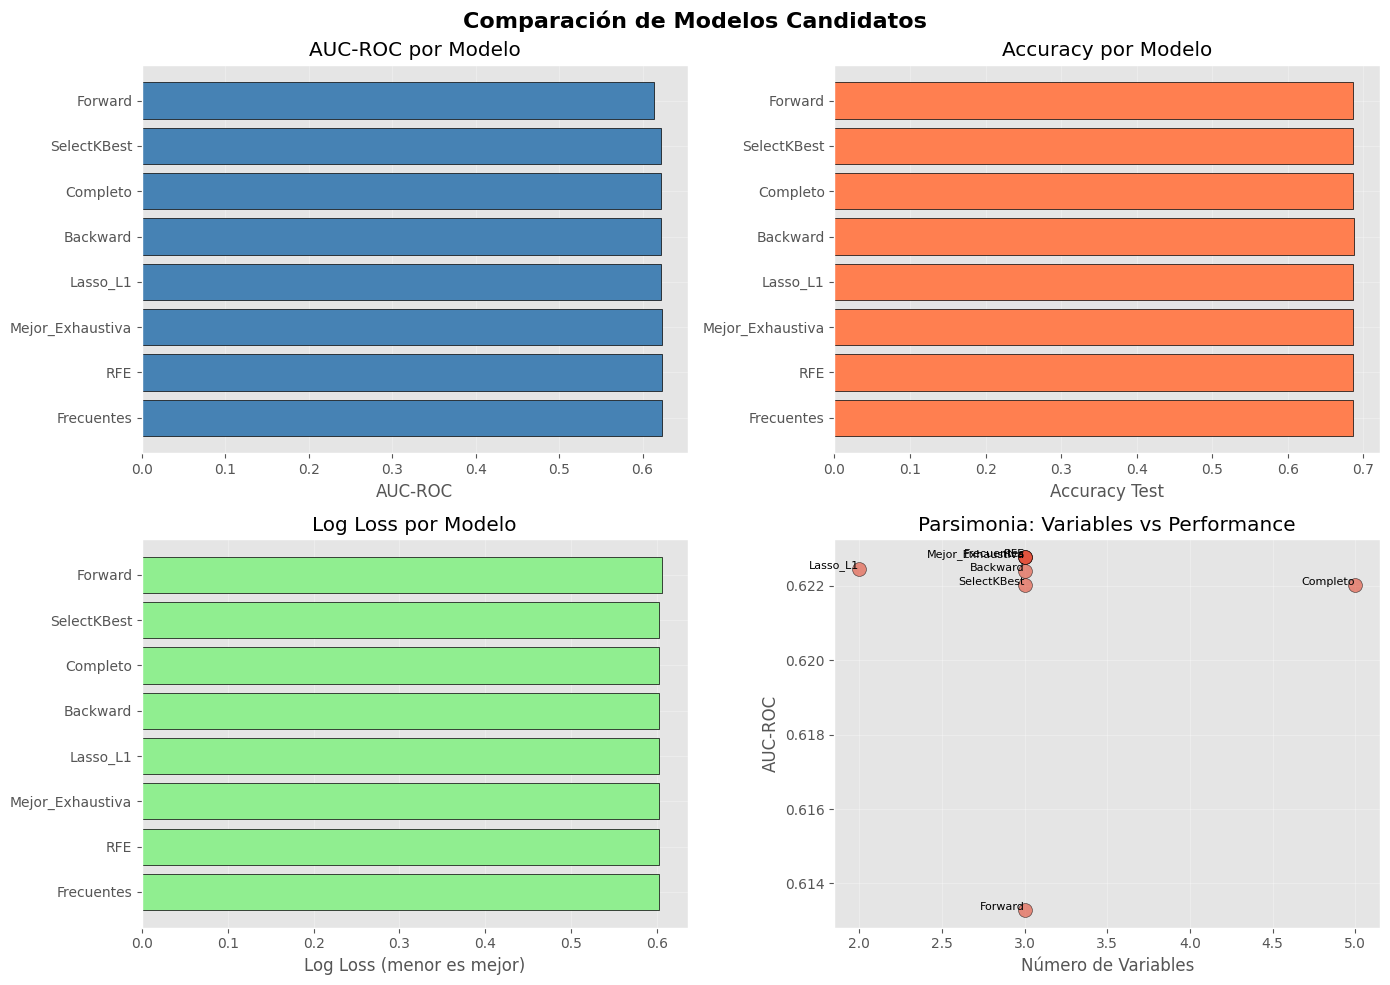

In [34]:
# ===============================================
# 7. COMPARACIÓN DE MODELOS Y SELECCIÓN DEL MEJOR
# ===============================================

print("\n" + "=" * 80)
print("COMPARACIÓN DE MODELOS")
print("=" * 80)

comparacion = pd.DataFrame({
    'Modelo': list(modelos_candidatos.keys()),
    'N° Variables': [m['n_vars'] for m in modelos_candidatos.values()],
    'Accuracy Train': [m['train_score'] for m in modelos_candidatos.values()],
    'Accuracy Test': [m['test_score'] for m in modelos_candidatos.values()],
    'AUC-ROC': [m['auc'] for m in modelos_candidatos.values()],
    'Log Loss': [m['log_loss'] for m in modelos_candidatos.values()]
})

comparacion['Diff_Train_Test'] = comparacion['Accuracy Train'] - comparacion['Accuracy Test']
comparacion = comparacion.sort_values('AUC-ROC', ascending=False)

print("\n📊 Tabla Comparativa de Modelos:")
print(comparacion.to_string(index=False))

print("\n" + "=" * 80)
print("CRITERIOS DE SELECCIÓN DEL MEJOR MODELO")
print("=" * 80)

mejor_auc_idx = comparacion['AUC-ROC'].idxmax()
mejor_auc = comparacion.loc[mejor_auc_idx, 'Modelo']
print(f"\n1️⃣ Mejor AUC-ROC: {mejor_auc} (AUC = {comparacion.loc[mejor_auc_idx, 'AUC-ROC']:.4f})")

mejor_logloss_idx = comparacion['Log Loss'].idxmin()
mejor_logloss = comparacion.loc[mejor_logloss_idx, 'Modelo']
print(f"2️⃣ Menor Log Loss: {mejor_logloss} (Log Loss = {comparacion.loc[mejor_logloss_idx, 'Log Loss']:.4f})")

mejor_overfit_idx = comparacion['Diff_Train_Test'].idxmin()
mejor_overfit = comparacion.loc[mejor_overfit_idx, 'Modelo']
print(f"3️⃣ Menor Overfitting: {mejor_overfit} (Diff = {comparacion.loc[mejor_overfit_idx, 'Diff_Train_Test']:.4f})")

comparacion['Score_Parsimonia'] = comparacion['AUC-ROC'] / (1 + 0.01 * comparacion['N° Variables'])
mejor_parsimonia_idx = comparacion['Score_Parsimonia'].idxmax()
mejor_parsimonia = comparacion.loc[mejor_parsimonia_idx, 'Modelo']
print(f"4️⃣ Mejor Parsimonia: {mejor_parsimonia} (Score = {comparacion.loc[mejor_parsimonia_idx, 'Score_Parsimonia']:.4f})")

# Modelo final seleccionado (por AUC)
modelo_final_nombre = mejor_auc
modelo_final_info = modelos_candidatos[modelo_final_nombre]
modelo_final = modelo_final_info['modelo']
variables_finales = modelo_final_info['variables']

print("\n" + "=" * 80)
print("🏆 MODELO FINAL SELECCIONADO")
print("=" * 80)
print(f"\n✅ Modelo: {modelo_final_nombre}")
print(f"✅ Variables: {variables_finales}")
print(f"✅ N° Variables: {len(variables_finales)}")
print(f"✅ Accuracy Test: {modelo_final_info['test_score']:.4f}")
print(f"✅ AUC-ROC: {modelo_final_info['auc']:.4f}")
print(f"✅ Log Loss: {modelo_final_info['log_loss']:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de Modelos Candidatos', fontsize=16, fontweight='bold')

axes[0, 0].barh(comparacion['Modelo'], comparacion['AUC-ROC'],
                color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('AUC-ROC')
axes[0, 0].set_title('AUC-ROC por Modelo')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].barh(comparacion['Modelo'], comparacion['Accuracy Test'],
                color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Accuracy Test')
axes[0, 1].set_title('Accuracy por Modelo')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].barh(comparacion['Modelo'], comparacion['Log Loss'],
                color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Log Loss (menor es mejor)')
axes[1, 0].set_title('Log Loss por Modelo')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(comparacion['N° Variables'], comparacion['AUC-ROC'],
                   s=100, alpha=0.6, edgecolors='black')
for idx, row in comparacion.iterrows():
    axes[1, 1].annotate(row['Modelo'],
                        (row['N° Variables'], row['AUC-ROC']),
                        fontsize=8, ha='right')
axes[1, 1].set_xlabel('Número de Variables')
axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_title('Parsimonia: Variables vs Performance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis detallado del modelo final


ANÁLISIS DETALLADO DEL MODELO FINAL

📊 Coeficientes del modelo:
    Variable  Coeficiente  Odds_Ratio
    talla_cm    -3.095656    0.045245
  edad_meses     0.551667    1.736145
talla_edad_z    -0.359437    0.698069

Intercepto: 0.7244

📐 Ecuación del modelo logístico:
log(p/(1-p)) = 0.7244 + (-3.0957) * talla_cm + (0.5517) * edad_meses + (-0.3594) * talla_edad_z

💡 Interpretación de Odds Ratios (p = probabilidad de Con_anemia):
  • talla_cm: Por cada unidad de aumento (en escala normalizada 0-1), las odds de anemia disminuyen 95.5%
  • edad_meses: Por cada unidad de aumento (en escala normalizada 0-1), las odds de anemia aumentan 73.6%
  • talla_edad_z: Por cada unidad de aumento (en escala normalizada 0-1), las odds de anemia disminuyen 30.2%


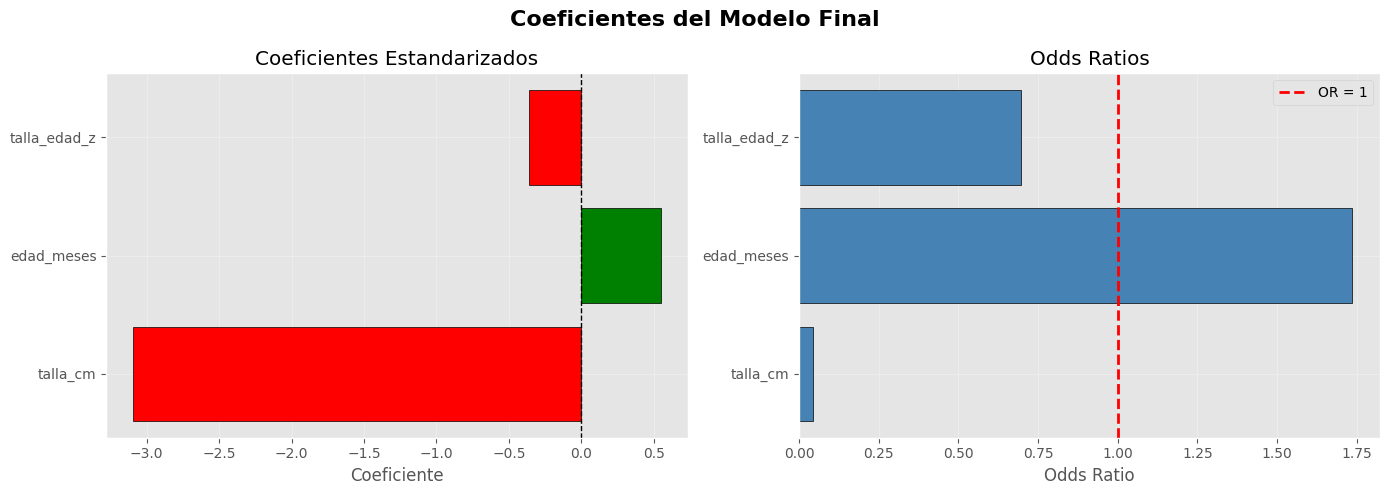


EVALUACIÓN DEL MODELO FINAL

📊 Validación Cruzada (10-fold):
  Scores: [0.69010239 0.68122867 0.68805461 0.68259386 0.68989071 0.68784153
 0.68920765 0.68237705 0.68442623 0.67827869]
  Media: 0.6854 (+/- 0.0079)

📊 Matriz de Confusión:
[[2463   48]
 [1099   52]]

📊 Reporte de Clasificación:
              precision    recall  f1-score   support

  Sin_anemia       0.69      0.98      0.81      2511
  Con_anemia       0.52      0.05      0.08      1151

    accuracy                           0.69      3662
   macro avg       0.61      0.51      0.45      3662
weighted avg       0.64      0.69      0.58      3662


📊 Métricas Detalladas:
  Accuracy: 0.6868
  Precision: 0.5200
  Recall (Sensibilidad): 0.0452
  F1-Score: 0.0831
  AUC-ROC: 0.6228
  Log Loss: 0.6021


In [35]:
# ======================================
# 8. ANÁLISIS DETALLADO DEL MODELO FINAL
# ======================================

print("\n" + "=" * 80)
print("ANÁLISIS DETALLADO DEL MODELO FINAL")
print("=" * 80)

X_train_final = X_train_scaled_df[variables_finales]
X_test_final = X_test_scaled_df[variables_finales]

coeficientes = pd.DataFrame({
    'Variable': variables_finales,
    'Coeficiente': modelo_final.coef_[0],
    'Odds_Ratio': np.exp(modelo_final.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\n📊 Coeficientes del modelo:")
print(coeficientes.to_string(index=False))
print(f"\nIntercepto: {modelo_final.intercept_[0]:.4f}")

print("\n📐 Ecuación del modelo logístico:")
ecuacion = f"log(p/(1-p)) = {modelo_final.intercept_[0]:.4f}"
for var, coef in zip(variables_finales, modelo_final.coef_[0]):
    ecuacion += f" + ({coef:.4f}) * {var}"
print(ecuacion)

print("\n💡 Interpretación de Odds Ratios (p = probabilidad de Con_anemia):")
for idx, row in coeficientes.iterrows():
    if row['Odds_Ratio'] > 1:
        cambio = (row['Odds_Ratio'] - 1) * 100
        print(f"  • {row['Variable']}: Por cada unidad de aumento (en escala normalizada 0-1), "
              f"las odds de anemia aumentan {cambio:.1f}%")
    else:
        cambio = (1 - row['Odds_Ratio']) * 100
        print(f"  • {row['Variable']}: Por cada unidad de aumento (en escala normalizada 0-1), "
              f"las odds de anemia disminuyen {cambio:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coeficientes del Modelo Final', fontsize=16, fontweight='bold')

colors = ['red' if x < 0 else 'green' for x in coeficientes['Coeficiente']]
axes[0].barh(coeficientes['Variable'], coeficientes['Coeficiente'],
             color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Coeficiente')
axes[0].set_title('Coeficientes Estandarizados')
axes[0].grid(True, alpha=0.3)

axes[1].barh(coeficientes['Variable'], coeficientes['Odds_Ratio'],
             color='steelblue', edgecolor='black')
axes[1].axvline(x=1, color='red', linestyle='--', linewidth=2, label='OR = 1')
axes[1].set_xlabel('Odds Ratio')
axes[1].set_title('Odds Ratios')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 9. EVALUACIÓN COMPLETA DEL MODELO FINAL
# ============================================================================

print("\n" + "=" * 80)
print("EVALUACIÓN DEL MODELO FINAL")
print("=" * 80)

y_pred_final = modelo_final.predict(X_test_final)
y_pred_proba_final = modelo_final.predict_proba(X_test_final)[:, 1]

cv_scores = cross_val_score(modelo_final, X_train_final, y_train, cv=10)
print(f"\n📊 Validación Cruzada (10-fold):")
print(f"  Scores: {cv_scores}")
print(f"  Media: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

cm = confusion_matrix(y_test, y_pred_final)
print(f"\n📊 Matriz de Confusión:")
print(cm)

print(f"\n📊 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_final,
                           target_names=['Sin_anemia', 'Con_anemia']))

print("\n📊 Métricas Detalladas:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall (Sensibilidad): {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"  AUC-ROC: {modelo_final_info['auc']:.4f}")
print(f"  Log Loss: {modelo_final_info['log_loss']:.4f}")

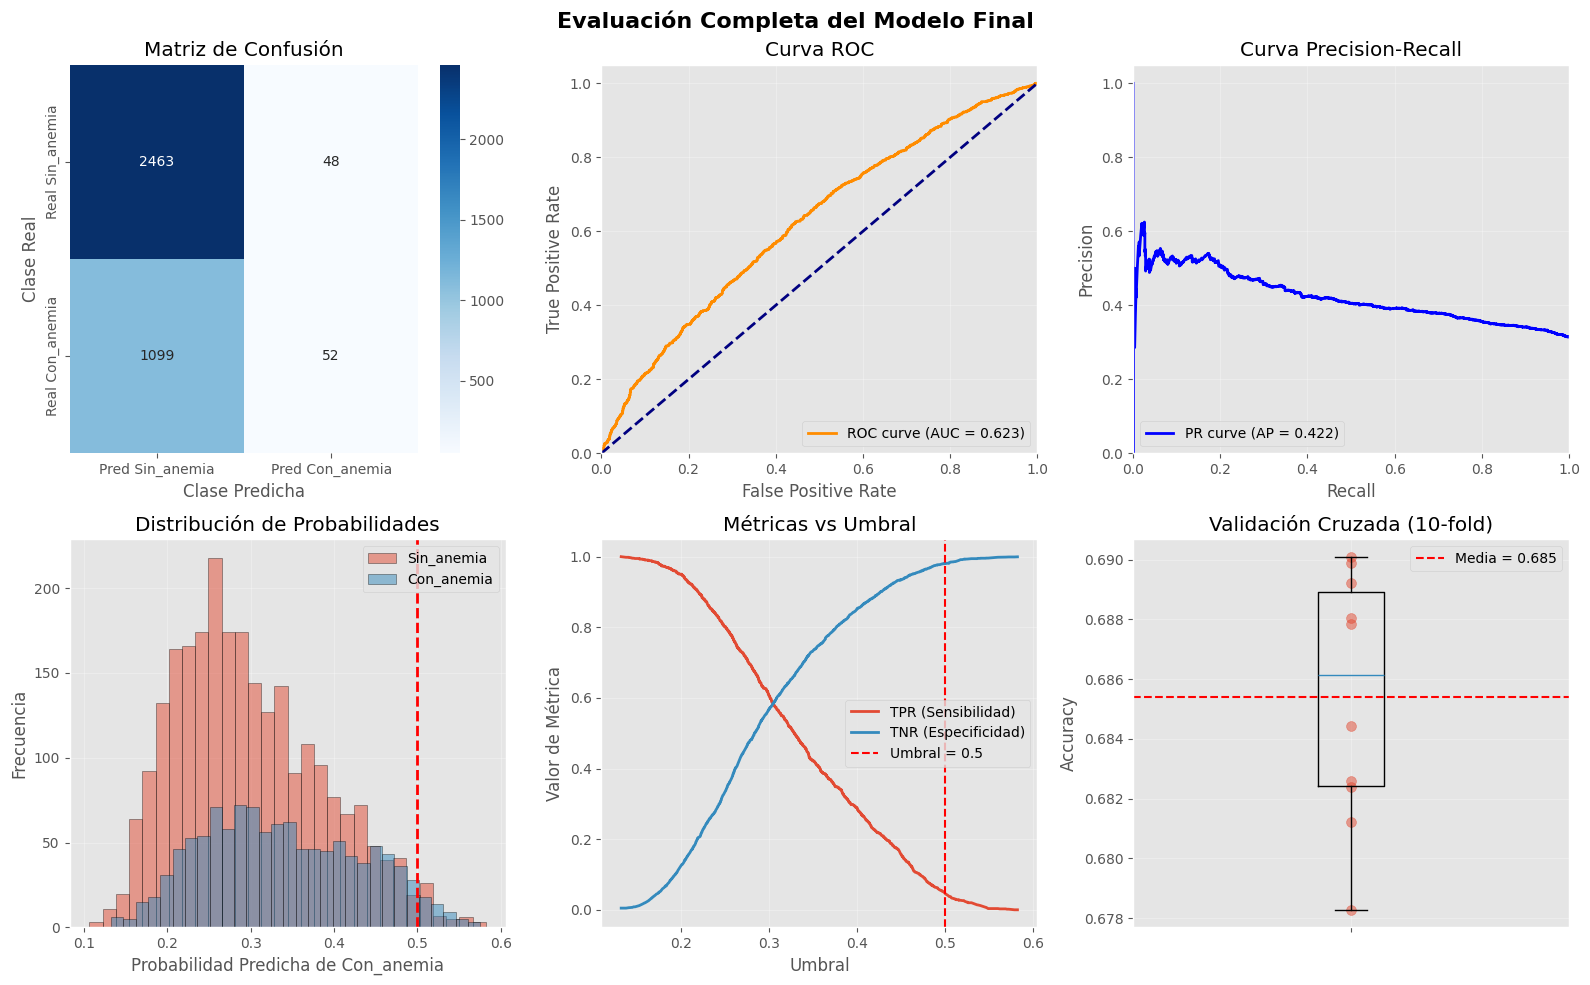

In [36]:
# ============================================================================
# 10. VISUALIZACIONES DEL MODELO FINAL
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Evaluación Completa del Modelo Final', fontsize=16, fontweight='bold')

# 10.1 Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Pred Sin_anemia', 'Pred Con_anemia'],
            yticklabels=['Real Sin_anemia', 'Real Con_anemia'])
axes[0, 0].set_title('Matriz de Confusión')
axes[0, 0].set_ylabel('Clase Real')
axes[0, 0].set_xlabel('Clase Predicha')

# 10.2 Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba_final)
roc_auc = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# 10.3 Curva Precision-Recall
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_final)
avg_precision = average_precision_score(y_test, y_pred_proba_final)

axes[0, 2].plot(recall, precision, color='blue', lw=2,
                label=f'PR curve (AP = {avg_precision:.3f})')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Curva Precision-Recall')
axes[0, 2].legend(loc="lower left")
axes[0, 2].grid(True, alpha=0.3)

# 10.4 Distribución de probabilidades
axes[1, 0].hist(y_pred_proba_final[y_test == 0], bins=30, alpha=0.5,
                label='Sin_anemia', edgecolor='black')
axes[1, 0].hist(y_pred_proba_final[y_test == 1], bins=30, alpha=0.5,
                label='Con_anemia', edgecolor='black')
axes[1, 0].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Probabilidad Predicha de Con_anemia')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Probabilidades')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 10.5 Métricas vs Umbral
axes[1, 1].plot(thresholds_roc[:-1], tpr[:-1], label='TPR (Sensibilidad)', linewidth=2)
axes[1, 1].plot(thresholds_roc[:-1], 1 - fpr[:-1], label='TNR (Especificidad)', linewidth=2)
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Umbral = 0.5')
axes[1, 1].set_xlabel('Umbral')
axes[1, 1].set_ylabel('Valor de Métrica')
axes[1, 1].set_title('Métricas vs Umbral')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 10.6 Validación cruzada
axes[1, 2].boxplot(cv_scores)
axes[1, 2].scatter([1]*len(cv_scores), cv_scores, alpha=0.5, s=50)
axes[1, 2].axhline(y=cv_scores.mean(), color='red', linestyle='--',
                   label=f'Media = {cv_scores.mean():.3f}')
axes[1, 2].set_ylabel('Accuracy')
axes[1, 2].set_title('Validación Cruzada (10-fold)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xticklabels([''])

plt.tight_layout()
plt.show()

## Análisis con statsmodels (p-valores y estadísticos del modelo final)

In [37]:
# ============================================================================
# 11. ANÁLISIS CON STATSMODELS (p-valores y estadísticos)
# ============================================================================

print("\n" + "=" * 80)
print("ANÁLISIS ESTADÍSTICO CON STATSMODELS")
print("=" * 80)

X_train_sm = sm.add_constant(X_train_final)
X_test_sm = sm.add_constant(X_test_final)

modelo_sm = sm.Logit(y_train, X_train_sm)
resultado_sm = modelo_sm.fit(disp=0)

print("\n📊 Resumen del modelo:")
print(resultado_sm.summary())

coef_sm = pd.DataFrame({
    'Variable': ['Intercepto'] + variables_finales,
    'Coeficiente': resultado_sm.params.values,
    'Std Error': resultado_sm.bse.values,
    'z-value': resultado_sm.tvalues.values,
    'p-value': resultado_sm.pvalues.values,
    'IC 95% Inferior': resultado_sm.conf_int()[0].values,
    'IC 95% Superior': resultado_sm.conf_int()[1].values
})

print("\n📊 Tabla de Coeficientes con Intervalos de Confianza:")
print(coef_sm.to_string(index=False))

print("\n💡 Significancia Estadística (α = 0.05):")
for idx, row in coef_sm.iterrows():
    if row['Variable'] != 'Intercepto':
        sig = "✅ Significativa" if row['p-value'] < 0.05 else "❌ No significativa"
        print(f"  {row['Variable']}: p-value = {row['p-value']:.4f} - {sig}")


ANÁLISIS ESTADÍSTICO CON STATSMODELS

📊 Resumen del modelo:
                           Logit Regression Results                           
Dep. Variable:           grupo_anemia   No. Observations:                14644
Model:                          Logit   Df Residuals:                    14640
Method:                           MLE   Df Model:                            3
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                 0.03378
Time:                        23:03:55   Log-Likelihood:                -8808.2
converged:                       True   LL-Null:                       -9116.2
Covariance Type:            nonrobust   LLR p-value:                3.700e-133
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7329      0.090      8.177      0.000       0.557       0.909
talla_cm        -4.2057      0.593     -7.089      0.000      -5

## Predicción en nuevos datos y análisis de sensibilidad

In [38]:
# ============================================================================
# 12. PREDICCIÓN EN NUEVOS DATOS
# ============================================================================

print("\n" + "=" * 80)
print("PREDICCIÓN EN NUEVOS DATOS")
print("=" * 80)

nuevos_datos = pd.DataFrame({
    var: [X_train[var].mean()] for var in variables_finales
})

print("\n📊 Datos de entrada (valores medios):")
print(nuevos_datos.to_string(index=False))

nuevos_datos_scaled = scaler.transform(
    pd.DataFrame({var: [X_train[var].mean()] for var in X.columns})
)[0]
nuevos_datos_scaled = pd.DataFrame([nuevos_datos_scaled], columns=X.columns)[variables_finales]

prediccion = modelo_final.predict(nuevos_datos_scaled)[0]
probabilidades = modelo_final.predict_proba(nuevos_datos_scaled)[0]

print(f"\n🎯 Resultados de la predicción:")
print(f"  Probabilidad Sin_anemia: {probabilidades[0]:.4f} ({probabilidades[0]*100:.2f}%)")
print(f"  Probabilidad Con_anemia: {probabilidades[1]:.4f} ({probabilidades[1]*100:.2f}%)")
clase_txt = 'Con_anemia' if int(prediccion) == 1 else 'Sin_anemia'
print(f"  Predicción Final: {clase_txt}")

print("\n📊 Análisis de Sensibilidad:")
print("Variando cada variable mientras las demás permanecen constantes:\n")

for var in variables_finales:
    print(f"Variable: {var}")
    valores_test = np.linspace(X_train[var].min(), X_train[var].max(), 5)

    for valor in valores_test:
        datos_completos = pd.DataFrame({v: [X_train[v].mean()] for v in X.columns})
        datos_completos[var] = valor
        datos_temp_scaled = scaler.transform(datos_completos)[0]
        datos_temp_scaled = pd.DataFrame([datos_temp_scaled], columns=X.columns)[variables_finales]

        prob = modelo_final.predict_proba(datos_temp_scaled)[0][1]
        print(f"  {var} = {valor:.2f} → P(Con_anemia) = {prob:.4f}")
    print()


PREDICCIÓN EN NUEVOS DATOS

📊 Datos de entrada (valores medios):
 talla_cm  edad_meses  talla_edad_z
88.801933   32.444756     -0.878526

🎯 Resultados de la predicción:
  Probabilidad Sin_anemia: 0.6931 (69.31%)
  Probabilidad Con_anemia: 0.3069 (30.69%)
  Predicción Final: Sin_anemia

📊 Análisis de Sensibilidad:
Variando cada variable mientras las demás permanecen constantes:

Variable: talla_cm
  talla_cm = 55.20 → P(Con_anemia) = 0.6933
  talla_cm = 71.15 → P(Con_anemia) = 0.5105
  talla_cm = 87.10 → P(Con_anemia) = 0.3247
  talla_cm = 103.05 → P(Con_anemia) = 0.1815
  talla_cm = 119.00 → P(Con_anemia) = 0.0928

Variable: edad_meses
  edad_meses = 6.00 → P(Con_anemia) = 0.2516
  edad_meses = 19.25 → P(Con_anemia) = 0.2785
  edad_meses = 32.50 → P(Con_anemia) = 0.3070
  edad_meses = 45.75 → P(Con_anemia) = 0.3371
  edad_meses = 59.00 → P(Con_anemia) = 0.3686

Variable: talla_edad_z
  talla_edad_z = -5.51 → P(Con_anemia) = 0.3473
  talla_edad_z = -3.25 → P(Con_anemia) = 0.3273
  tall

## Resumen ejecutivo

In [39]:
# ============================================================================
# 13. RESUMEN EJECUTIVO
# ============================================================================

print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO")
print("=" * 80)

print(f"""
🎯 MODELO FINAL SELECCIONADO: {modelo_final_nombre}

📊 CARACTERÍSTICAS DEL MODELO:
   • Variable dependiente: grupo_anemia (0=Sin_anemia, 1=Con_anemia)
   • Variables incluidas: {len(variables_finales)}
   • Variables: {', '.join(variables_finales)}

📈 PERFORMANCE:
   • Accuracy (Train): {modelo_final_info['train_score']:.4f}
   • Accuracy (Test): {modelo_final_info['test_score']:.4f}
   • AUC-ROC: {modelo_final_info['auc']:.4f}
   • Log Loss: {modelo_final_info['log_loss']:.4f}
   • CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

📐 ECUACIÓN DEL MODELO:
   {ecuacion}

✅ VARIABLES MÁS IMPORTANTES (por magnitud de coeficiente):
""")

for idx, row in coeficientes.head(3).iterrows():
    print(f"   {idx+1}. {row['Variable']}: β = {row['Coeficiente']:.4f}, OR = {row['Odds_Ratio']:.4f}")

print(f"""
💡 RECOMENDACIONES:
   • El modelo muestra {'buen' if modelo_final_info['auc'] > 0.8 else 'moderado'} poder discriminativo (AUC = {modelo_final_info['auc']:.4f})
   • {'No se detecta' if abs(modelo_final_info['train_score'] - modelo_final_info['test_score']) < 0.05 else 'Se detecta'} overfitting significativo
   • Se evaluaron {len(modelos_candidatos)} modelos candidatos
   • Revisar la tabla de p-valores de statsmodels para confirmar significancia individual de cada predictor
""")

print("=" * 80)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 80)


RESUMEN EJECUTIVO

🎯 MODELO FINAL SELECCIONADO: Frecuentes

📊 CARACTERÍSTICAS DEL MODELO:
   • Variable dependiente: grupo_anemia (0=Sin_anemia, 1=Con_anemia)
   • Variables incluidas: 3
   • Variables: talla_cm, edad_meses, talla_edad_z

📈 PERFORMANCE:
   • Accuracy (Train): 0.6850
   • Accuracy (Test): 0.6868
   • AUC-ROC: 0.6228
   • Log Loss: 0.6021
   • CV Score: 0.6854 ± 0.0039

📐 ECUACIÓN DEL MODELO:
   log(p/(1-p)) = 0.7244 + (-3.0957) * talla_cm + (0.5517) * edad_meses + (-0.3594) * talla_edad_z

✅ VARIABLES MÁS IMPORTANTES (por magnitud de coeficiente):

   1. talla_cm: β = -3.0957, OR = 0.0452
   2. edad_meses: β = 0.5517, OR = 1.7361
   3. talla_edad_z: β = -0.3594, OR = 0.6981

💡 RECOMENDACIONES:
   • El modelo muestra moderado poder discriminativo (AUC = 0.6228)
   • No se detecta overfitting significativo
   • Se evaluaron 8 modelos candidatos
   • Revisar la tabla de p-valores de statsmodels para confirmar significancia individual de cada predictor

✅ ANÁLISIS COMPLETA